In [1]:
import numpy as np
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import contextily as ctx
import osmnx as ox
from shapely.geometry import LineString
import random
from pointpats import k_test

In [ ]:
chemin_tous_agents = " "
chemin_imprimeurs = " "
chemin_dessinateurs = " "

gdf_agents = gpd.read_file(chemin_tous_agents, layer="noeuds").to_crs(epsg=2154)
gdf_imprimeurs = gpd.read_file(chemin_imprimeurs, layer="imprimeurs_dessinateurs").to_crs(epsg=2154)
gdf_dessinateurs = gpd.read_file(chemin_dessinateurs, layer="imprimeurs_dessinateurs").to_crs(epsg=2154)

In [3]:
gdf_agents.head()

,uriAgent,nomagent,typeAgent,dateDebutMin,dateFinMax,adresse,degre,label,weighted_degree,community,component_id,accessibilite,distance_moyenne,geometry
0,http://rdf.geohistoricaldata.org/id/museeCarna...,hardydudley,Dessinateur,1890,1900,33 r. Fortu-ny,0,"Hardy, Dudley",0,0,24,0,0.0,POINT (649239.875 6864991.008)
1,http://rdf.geohistoricaldata.org/id/museeCarna...,jolyediteurdemusique,Imprimeur,1880,1900,14 Renard,1,Joly (Éditeur de musique),2,269,0,987,7.100719424460432,POINT (652434.267 6862190.222)
2,http://rdf.geohistoricaldata.org/id/museeCarna...,imprimerieathomas,Imprimeur,1880,1900,r. des Fourneaux,0,Imprimerie A. Thomas,0,1,25,0,0.0,POINT (648993.263 6859101.836)
3,http://rdf.geohistoricaldata.org/id/museeCarna...,imprimeriedubertfils,Imprimeur,1886,1886,13 rue de la Chapelle,0,Imprimerie Dubert fils,0,2,26,0,0.0,POINT (653001.469 6865239.039)
4,http://rdf.geohistoricaldata.org/id/museeCarna...,bernig,Dessinateur,1880,1900,9 Charlot,2,"Berni, G.",2,3,3,2,1.0,POINT (653076.817 6862535.926)


In [ ]:
# 1. Chargement du GeoJSON du réseau viaire 1888
gdf_rues = gpd.read_file(" ")

# Projection en mètres (EPSG:2154 Lambert-93)
if gdf_rues.crs is None or gdf_rues.crs.is_geographic:
    gdf_rues = gdf_rues.to_crs(epsg=2154)

# 2. Construction du graphe NetworkX
G_1888 = nx.Graph()
G_1888.graph["crs"] = "EPSG:2154"

for geom in gdf_rues.geometry:
    if geom is None:
        continue
    # Gestion des LineString et MultiLineString
    lines = [geom] if geom.geom_type == 'LineString' else list(geom.geoms)
    for line in lines:
        coords = list(line.coords)
        u = coords[0]   # Point de départ (x, y)
        v = coords[-1]  # Point d'arrivée (x, y)
        length = line.length  # Longueur réelle en mètres
        
        G_1888.add_edge(u, v, length=length)

# 3. Projection des agents sur le nœud du réseau le plus proche
nodes_list = list(G_1888.nodes())
nodes_array = np.array(nodes_list)

# Arbre spatial k-d pour recherche ultra-rapide
tree = cKDTree(nodes_array)

coords_dessinateurs = np.column_stack([
    gdf_dessinateurs.geometry.x, gdf_dessinateurs.geometry.y
])
_, indices_des = tree.query(coords_dessinateurs)
gdf_dessinateurs["node_id"] = [nodes_list[i] for i in indices_des]

# --- Projection des imprimeurs sur le nœud du réseau le plus proche ---
coords_imprimeurs = np.column_stack([
    gdf_imprimeurs.geometry.x, gdf_imprimeurs.geometry.y
])
_, indices_imp = tree.query(coords_imprimeurs)
gdf_imprimeurs["node_id"] = [nodes_list[i] for i in indices_imp]

In [5]:
print(gdf_dessinateurs["node_id"].isna().sum())
print(gdf_imprimeurs["node_id"].isna().sum())

0
0


In [ ]:
def analyser_ripley(gpkg_path, layer_name, nom_couche_affich, epsg=2154, n_simulations=99, ylim=None):
    # 1. Chargement de la couche
    gdf = gpd.read_file(gpkg_path, layer=layer_name)

    # 2. Reprojection en mètres si la couche est en degrés
    if gdf.crs is None or gdf.crs.is_geographic:
        gdf = gdf.to_crs(epsg=epsg)

    # 3. Extraction des coordonnées (N, 2) et de l'emprise
    coords = np.column_stack([gdf.geometry.x, gdf.geometry.y])
    bounding_box = gdf.total_bounds

    # 4. Calcul du test de Ripley avec simulations Monte-Carlo
    res = k_test(coords, hull=bounding_box, support=(0, 2500, 100), n_simulations=99, keep_simulations=True)

    # 5. Calcul de l'enveloppe de confiance à 95 %
    support = res.support
    observed = res.statistic
    sims = res.simulations

    low_bound = np.percentile(sims, 2.5, axis=0)
    high_bound = np.percenti, fontsize=12le(sims, 97.5, axis=0)

    ax = plt.gca()
    # 6. Affichage du graphique
    if ylim:
        ax.set_ylim(ylim)
    ax.fill_between(support, low_bound, high_bound, color='green', alpha=0.3, label='Enveloppe CSR 95 %')
    ax.plot(support, observed, color='red', linewidth=2, label=f'K(r) observé ({nom_couche_affich})')

    ax.set_xlabel('Distance r (mètres)', fontsize=12)
    ax.set_ylabel('K(r)', fontsize=12)
    ax.set_title(f'Analyse de Ripley : {nom_couche_affich}', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)

    return res, gdf

In [ ]:
def ripley_bivarie(gdf1, gdf2, radii, n_simulations=99, ylim=None):
    """
    gdf1 : GeoDataFrame de la population source (ex: dessinateurs)
    gdf2 : GeoDataFrame de la population cible (ex: imprimeurs)
    radii : tableau des rayons r à tester (ex: np.linspace(10, 1000, 50))
    """
    # Extraction des coordonnées projetées en mètres
    c1 = np.column_stack([gdf1.geometry.x, gdf1.geometry.y])
    c2 = np.column_stack([gdf2.geometry.x, gdf2.geometry.y])
    
    n1, n2 = len(c1), len(c2)
    
    # Calcul de l'aire globale (Bounding Box combinée)
    bounds1, bounds2 = gdf1.total_bounds, gdf2.total_bounds
    xmin = min(bounds1[0], bounds2[0])
    ymin = min(bounds1[1], bounds2[1])
    xmax = max(bounds1[2], bounds2[2])
    ymax = max(bounds1[3], bounds2[3])
    area = (xmax - xmin) * (ymax - ymin)
    
    # 1. Calcul de K12(r) observé
    tree2 = cKDTree(c2)
    # Compte le nombre d'imprimeurs à distance r de chaque dessinateur
    counts = tree2.count_neighbors(cKDTree(c1), radii)
    k12_obs = (area / (n1 * n2)) * counts
    
    # 2. Simulations Monte-Carlo (Indépendance par re-localisation aléatoire de P2)
    sims = np.zeros((n_simulations, len(radii)))
    for s in range(n_simulations):
        rand_x = np.random.uniform(xmin, xmax, n2)
        rand_y = np.random.uniform(ymin, ymax, n2)
        c2_sim = np.column_stack([rand_x, rand_y])
        
        tree_sim = cKDTree(c2_sim)
        counts_sim = tree_sim.count_neighbors(cKDTree(c1), radii)
        sims[s, :] = (area / (n1 * n2)) * counts_sim

    # 3. Calcul de l'enveloppe 95 %
    low_bound = np.percentile(sims, 2.5, axis=0)
    high_bound = np.percentile(sims, 97.5, axis=0)

    

    # 4. Tracé
    ax = plt.gca()
    if ylim:
        ax.set_ylim(ylim)
    ax.fill_between(radii, low_bound, high_bound, color='green', alpha=0.3, label='Enveloppe d\'indépendance 95 %')
    ax.plot(radii, k12_obs, color='red', linewidth=2, label='K12(r) Dessinateurs -> Imprimeurs')
    ax.set_xlabel('Distance r (mètres)', fontsize=12)
    ax.set_ylabel('K12(r)', fontsize=12)
    ax.set_title('Analyse de Ripley Bivariée (Cross-K)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)


In [8]:
gdf_imprimeurs = gpd.read_file(chemin_imprimeurs, layer="imprimeurs_dessinateurs").to_crs(epsg=2154)
gdf_dessinateurs = gpd.read_file(chemin_dessinateurs, layer="imprimeurs_dessinateurs").to_crs(epsg=2154)
# 4. Définition de la plage de recherche (ex. de 10 m à 1 000 m avec 50 étapes)
radii = np.linspace(10, 2500, 100)

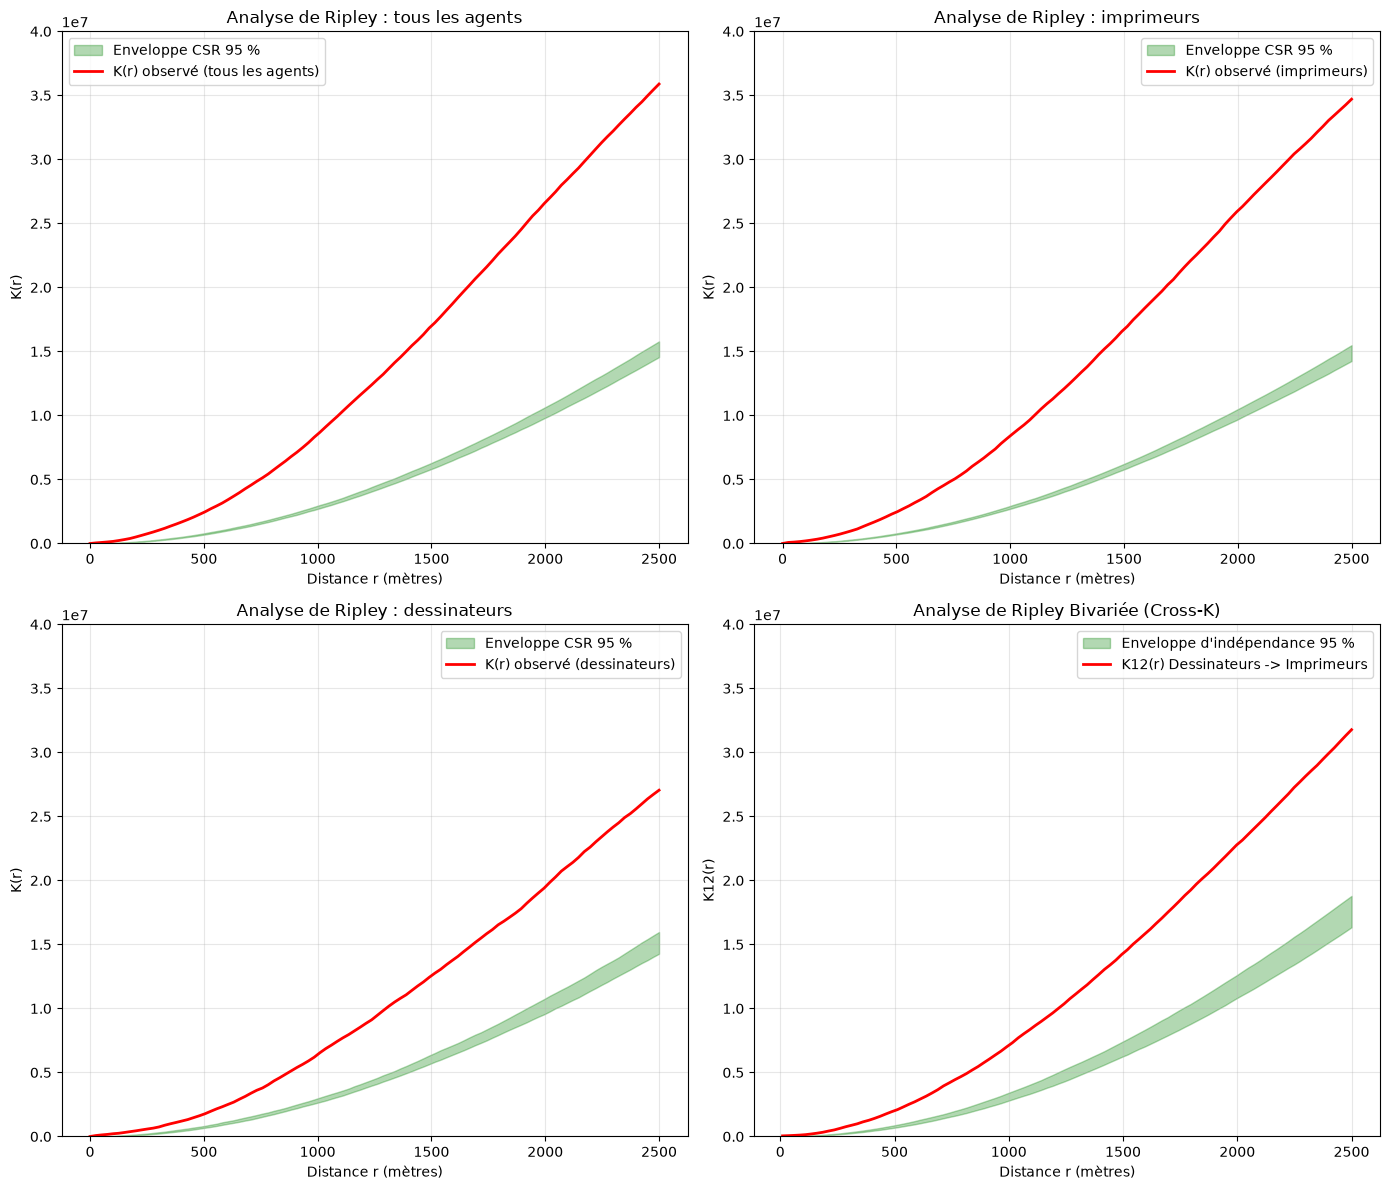

In [ ]:
# 1. Création de la grille 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 16))

# 2. Haut-gauche : Tous les agents
plt.sca(axes[0, 0])
res_agents, gdf_agents_all = analyser_ripley(
    chemin_tous_agents, layer_name="noeuds", nom_couche_affich="tous les agents"
)

# 3. Haut-droit : Imprimeurs
plt.sca(axes[0, 1])
res_imprimeurs, gdf_imprimeurs = analyser_ripley(
    chemin_imprimeurs,
    layer_name="imprimeurs_dessinateurs",
    nom_couche_affich="imprimeurs",
)

# 4. Bas-gauche : Dessinateurs
plt.sca(axes[1, 0])
res_dessinateurs, gdf_dessinateurs = analyser_ripley(
    chemin_dessinateurs,
    layer_name="imprimeurs_dessinateurs",
    nom_couche_affich="dessinateurs",
)

# 5. Bas-droit : Analyse bivariée
plt.sca(axes[1, 1])
ripley_bivarie(gdf_dessinateurs, gdf_imprimeurs, radii, n_simulations=99)
k_max = 40000000

#axes[1, 1].set_title("Ripley Bivarié (Dessinateurs / Imprimeurs)")

for ax_row in axes:
  for ax in ax_row:
    ax.set_ylim(0, k_max)

plt.tight_layout()
plt.show()

In [ ]:
# FONCTION D'AFFICHAGE D'HISTOS 

def tracer_cadran(ax, dist, titre, x_label, couleur):
  """Calcule Q1, Q2, Q3 et trace un cadran unique pour une distribution."""
  q1, med, q3 = np.percentile(dist, [25, 50, 75])

  print(f"=== {titre} ===")
  print(f"  Q1 (25%)  : {q1:.0f} m")
  print(f"  Médiane   : {med:.0f} m")
  print(f"  Q3 (75%)  : {q3:.0f} m\n")

  # Histogramme
  ax.hist(
      dist,
      bins=35,
      color=couleur,
      alpha=0.65,
      edgecolor="black",
      density=True,
  )

  # Repères visuels pour Q1, Médiane (Q2) et Q3
  ax.axvline(
      med,
      color="red",
      linestyle="-",
      linewidth=2,
      label=f"Médiane (Q2) : {med:.0f} m",
  )
  ax.axvline(
      q1,
      color="pink",
      linestyle="--",
      linewidth=1.5,
      alpha=0.8,
      label=f"Q1 : {q1:.0f} m",
  )
  ax.axvline(
      q3,
      color="pink",
      linestyle="--",
      linewidth=1.5,
      alpha=0.8,
      label=f"Q3 : {q3:.0f} m",
  )

  ax.set_title(titre, fontsize=12, fontweight="bold")
  ax.set_xlabel(x_label)
  ax.set_ylabel("Densité")
  ax.legend(fontsize=12, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1)
  ax.grid(True, alpha=0.25)


# ==============================================================================
# GENERATION DES DONNEES ET GRILLE 2x2 (4 CADRANS)
def executer_analyse_4_cadrans(
    G, gdf_dessinateurs, gdf_imprimeurs, dist_obs_vo, dist_obs_dijkstra, n_echantillons=3000
):
  """Gère le tirage aléatoire et génère la figure à 4 cadrans (2x2)."""
  n_des = len(gdf_dessinateurs)
  n_imp = len(gdf_imprimeurs)

  coords_des = np.column_stack([gdf_dessinateurs.geometry.x, gdf_dessinateurs.geometry.y])
  coords_imp = np.column_stack([gdf_imprimeurs.geometry.x, gdf_imprimeurs.geometry.y])
  nodes_des = list(gdf_dessinateurs["node_id"])
  nodes_imp = list(gdf_imprimeurs["node_id"])


  # --- A. Tirage aléatoire des paires d'agents (Modèle nul) ---
  idx1 = np.random.choice(n_des, size=n_echantillons, replace=True)
  idx2 = np.random.choice(n_imp, size=n_echantillons, replace=True)
  mask = idx1 != idx2
  idx1, idx2 = idx1[mask], idx2[mask]

  # Distances aléatoires à vol d'oiseau
  dist_rand_vo = np.linalg.norm(coords_des[idx1] - coords_imp[idx2], axis=1)

  # --- B. Distances aléatoires sur le réseau (Dijkstra) ---
  dist_rand_dijkstra = []
  for i1, i2 in zip(idx1, idx2):
    u = nodes_des[i1]
    v = nodes_imp[i2]

    # Vérification que les nœuds existent dans le graphe G
    if u in G and v in G:
      try:
        d = nx.shortest_path_length(G, source=u, target=v, weight="length")
        dist_rand_dijkstra.append(d)
      except nx.NetworkXNoPath:
        continue

  dist_rand_dijkstra = np.array(dist_rand_dijkstra)

  # --- C. Visualisation (2x2 = 4 Cadrans) ---
  fig, axes = plt.subplots(2, 2, figsize=(15, 10))

  # Ligne du haut : Vol d'oiseau (Réel à gauche, Hasard à droite)
  tracer_cadran(
      axes[0, 0],
      dist_obs_vo,
      "1. Vol d'oiseau — RÉEL",
      "Distance (mètres)",
      '#1F77B4',
  )
  tracer_cadran(
      axes[0, 1],
      dist_rand_vo,
      "2. Vol d'oiseau — HASARD",
      "Distance (mètres)",
      '#FF7F0E',
  )

  # Ligne du bas : Dijkstra (Réel à gauche, Hasard à droite)
  tracer_cadran(
      axes[1, 0],
      dist_obs_dijkstra,
      "3. Réseau viaire (1888) — RÉEL",
      "Distance (mètres)",
      "#2CA02C",
  )
  tracer_cadran(
      axes[1, 1],
      dist_rand_dijkstra,
      "4. Réseau viaire (1888) — HASARD",
      "Distance (mètres)",
      '#9467BD',
  )

  plt.suptitle(
      "Analyse comparative des distributions de distances",
      fontsize=14,
      fontweight="bold",
  )
  plt.tight_layout()
  plt.show()

In [11]:
print(gdf_agents.columns.tolist())

['uriAgent', 'nomagent', 'typeAgent', 'dateDebutMin', 'dateFinMax', 'adresse', 'degre', 'label', 'weighted_degree', 'community', 'component_id', 'accessibilite', 'distance_moyenne', 'geometry']


In [12]:
# Projection des dessinateurs sur le réseau
coords_dessinateurs = np.column_stack([
    gdf_dessinateurs.geometry.x, gdf_dessinateurs.geometry.y
])
_, indices_des = tree.query(coords_dessinateurs)
gdf_dessinateurs["node_id"] = [nodes_list[i] for i in indices_des]

# Projection des imprimeurs sur le réseau
coords_imprimeurs = np.column_stack([
    gdf_imprimeurs.geometry.x, gdf_imprimeurs.geometry.y
])
_, indices_imp = tree.query(coords_imprimeurs)
gdf_imprimeurs["node_id"] = [nodes_list[i] for i in indices_imp]

print("node_id ajouté :", "node_id" in gdf_dessinateurs.columns, "node_id" in gdf_imprimeurs.columns)

node_id ajouté : True True


Nombre de liens valides traités : 180
=== 1. Vol d'oiseau — RÉEL ===
  Q1 (25%)  : 2076 m
  Médiane   : 3572 m
  Q3 (75%)  : 4933 m

=== 2. Vol d'oiseau — HASARD ===
  Q1 (25%)  : 1949 m
  Médiane   : 3183 m
  Q3 (75%)  : 4465 m

=== 3. Réseau viaire (1888) — RÉEL ===
  Q1 (25%)  : 2347 m
  Médiane   : 3823 m
  Q3 (75%)  : 5231 m

=== 4. Réseau viaire (1888) — HASARD ===
  Q1 (25%)  : 2293 m
  Médiane   : 3661 m
  Q3 (75%)  : 5050 m



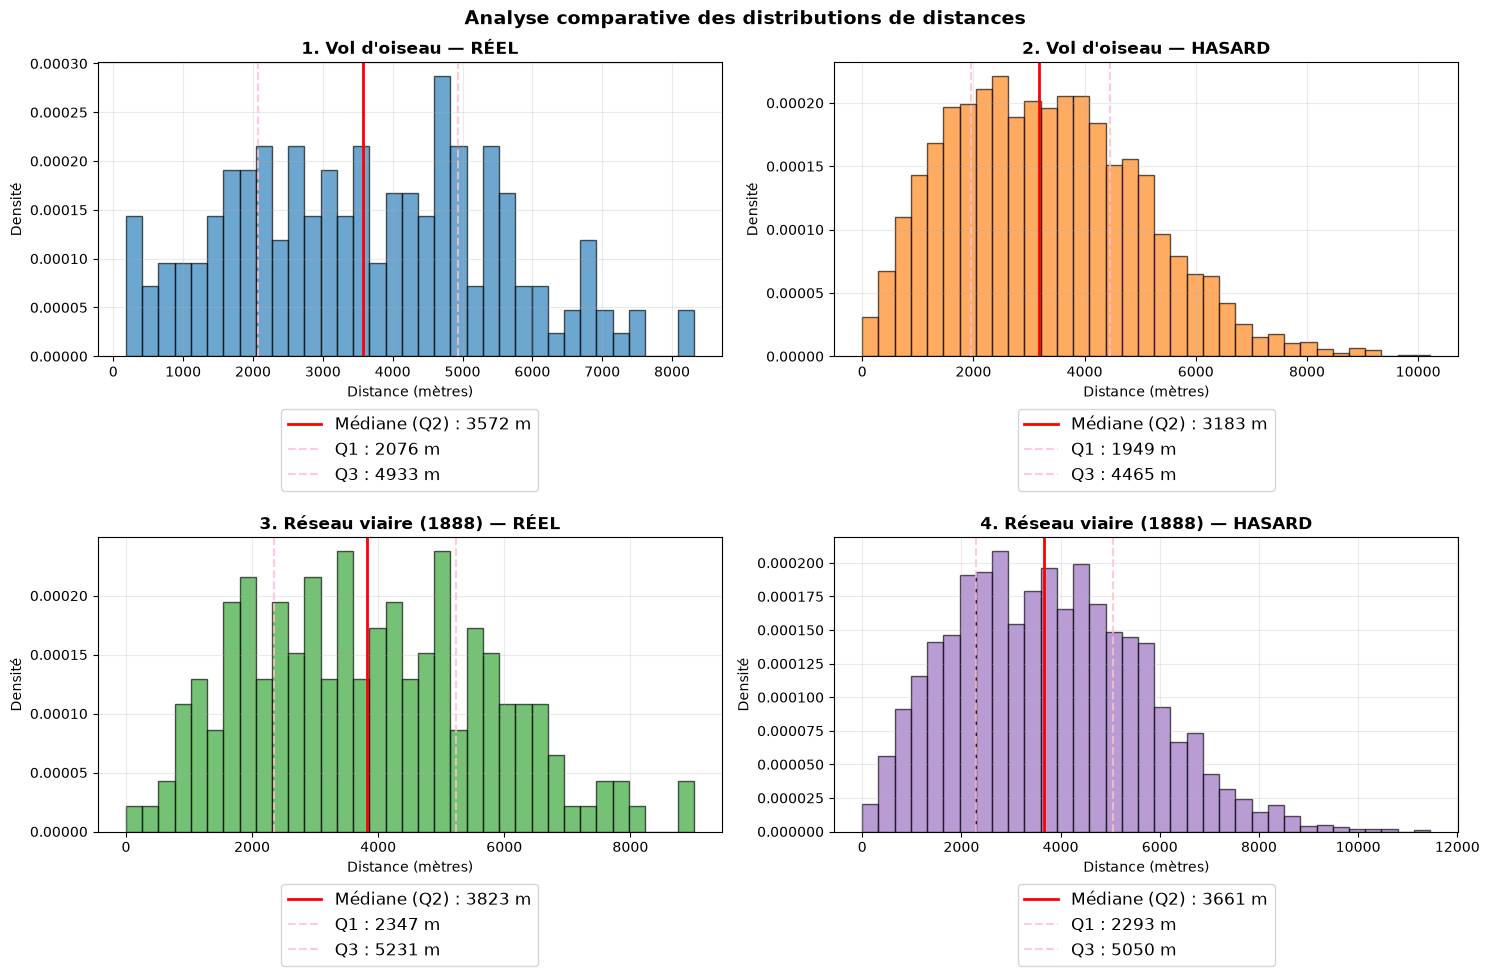

In [ ]:
# Chargement de la couche des liens
gdf_liens = gpd.read_file(chemin_tous_agents, layer="liens").to_crs(epsg=2154)

uri_to_node_des = dict(zip(gdf_dessinateurs["uriAgent"], gdf_dessinateurs["node_id"]))
uri_to_node_imp = dict(zip(gdf_imprimeurs["uriAgent"], gdf_imprimeurs["node_id"]))

dist_vo_reelles_list = []
dist_dijkstra_reelles_list = []

for _, row in gdf_liens.iterrows():
  node_u = uri_to_node_des.get(row["source_uri"]) or uri_to_node_imp.get(row["source_uri"])
  node_v = uri_to_node_imp.get(row["target_uri"]) or uri_to_node_des.get(row["target_uri"])

  source_est_des = row["source_uri"] in uri_to_node_des
  source_est_imp = row["source_uri"] in uri_to_node_imp
  target_est_des = row["target_uri"] in uri_to_node_des
  target_est_imp = row["target_uri"] in uri_to_node_imp

  lien_croise = (source_est_des and target_est_imp) or (source_est_imp and target_est_des)
  if not lien_croise:
    continue

  geom_length = row.geometry.length

  # Vérification de l'existence des nœuds et calcul de Dijkstra
  if node_u in G_1888 and node_v in G_1888:
    try:
      d = nx.shortest_path_length(
          G_1888, source=node_u, target=node_v, weight="length"
      )
      # On ajoute les deux valeurs en même temps pour garder l'alignement parfait
      dist_vo_reelles_list.append(geom_length)
      dist_dijkstra_reelles_list.append(d)

    except nx.NetworkXNoPath:
      continue
  else:
    continue

# Conversion en tableaux numpy
dist_vo_reelles = np.array(dist_vo_reelles_list)
dist_dijkstra_reelles = np.array(dist_dijkstra_reelles_list)

print(f"Nombre de liens valides traités : {len(dist_vo_reelles)}")

# 4. Lancement de l'analyse
executer_analyse_4_cadrans(
    G=G_1888,
    gdf_dessinateurs=gdf_dessinateurs,
    gdf_imprimeurs=gdf_imprimeurs,
    dist_obs_vo=dist_vo_reelles,
    dist_obs_dijkstra=dist_dijkstra_reelles,
    n_echantillons=3000,
)

In [32]:
def convertir_en_graphe_osmnx(G):
    # 1. Passage en MultiDiGraph (format attendu par osmnx)
    G_multi = nx.MultiDiGraph(G)
    G_multi.graph["crs"] = "EPSG:2154"

    # 2. Ajout des attributs x, y à partir de l'identifiant (tuple de coords)
    for node, data in G_multi.nodes(data=True):
        x, y = node  # le nœud EST la coordonnée
        data["x"] = x
        data["y"] = y

    return G_multi

G_1888_osmnx = convertir_en_graphe_osmnx(G_1888)

edges_g = ox.graph_to_gdfs(G_1888_osmnx, nodes=False)

In [38]:
dist_vo_reelles_list = []
dist_dijkstra_reelles_list = []
chemins_dijkstra_geom = []

# Parcours ligne par ligne avec calcul et extraction de la géométrie du chemin
for _, row in gdf_liens.iterrows():
    node_u = uri_to_node_des.get(row["source_uri"]) or uri_to_node_imp.get(row["source_uri"])
    node_v = uri_to_node_imp.get(row["target_uri"]) or uri_to_node_des.get(row["target_uri"])

    # On ne garde le lien que s'il relie bien UN dessinateur ET UN imprimeur
    source_est_des = row["source_uri"] in uri_to_node_des
    source_est_imp = row["source_uri"] in uri_to_node_imp
    target_est_des = row["target_uri"] in uri_to_node_des
    target_est_imp = row["target_uri"] in uri_to_node_imp

    lien_croise = (source_est_des and target_est_imp) or (source_est_imp and target_est_des)
    if not lien_croise:
        continue

    geom_length = row.geometry.length

    # Vérification de l'existence des nœuds et calcul Dijkstra + Géométrie
    if node_u in G_1888 and node_v in G_1888:
        try:
            path_nodes = nx.shortest_path(G_1888, source=node_u, target=node_v, weight="length")
            d = nx.shortest_path_length(G_1888, source=node_u, target=node_v, weight="length")
            
            if len(path_nodes) < 2:
                continue

            # Extraction des géométries des arêtes du chemin
            edge_geoms = []
            for u, v in zip(path_nodes[:-1], path_nodes[1:]):
                edge_data = G_1888.get_edge_data(u, v)
                if edge_data:
                    if isinstance(G_1888, (nx.MultiGraph, nx.MultiDiGraph)):
                        first_key = list(edge_data.keys())[0]
                        edge_attrs = edge_data[first_key]
                    else:
                        edge_attrs = edge_data

                    edge_geom = edge_attrs.get("geometry")
                    if edge_geom is not None:
                        edge_geoms.append(edge_geom)
                    else:
                        # Fallback en ligne droite si l'arête n'a pas de géométrie enregistrée
                        ux, uy = G_1888.nodes[u].get("x", 0), G_1888.nodes[u].get("y", 0)
                        vx, vy = G_1888.nodes[v].get("x", 0), G_1888.nodes[v].get("y", 0)
                        if (ux, uy) != (0, 0) and (vx, vy) != (0, 0):
                            edge_geoms.append(LineString([(ux, uy), (vx, vy)]))

            if edge_geoms:
                chemin_geom = unary_union(edge_geoms)
                if isinstance(chemin_geom, MultiLineString):
                    chemin_geom = linemerge(chemin_geom)

                dist_vo_reelles_list.append(geom_length)
                dist_dijkstra_reelles_list.append(d)
                chemins_dijkstra_geom.append(chemin_geom)

        except (nx.NetworkXNoPath, KeyError):
            continue
    else:
        continue

# Conversion en tableaux numpy
dist_vo_reelles = np.array(dist_vo_reelles_list)
dist_dijkstra_reelles = np.array(dist_dijkstra_reelles_list)

print(f"Nombre de liens valides traités : {len(dist_vo_reelles)}")

# Création du GeoDataFrame combinant données statistiques et géométries des chemins
gdf_chemins_dijkstra = gpd.GeoDataFrame(
    {
        "dist_vo": dist_vo_reelles,
        "dist_dijkstra": dist_dijkstra_reelles
    },
    geometry=chemins_dijkstra_geom,
    crs="EPSG:2154"
)

Nombre de liens valides traités : 0
